In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/raw/Sample-Superstore.csv', encoding='cp1252')
pd.set_option('display.max_columns',100)

# Data understanding and Cleaning

In [3]:
df.drop(columns=['Country'],inplace = True)

In [4]:
df['Ship Mode'] = df['Ship Mode'].astype('category')
df['Segment'] = df['Segment'].astype('category')
df['State'] = df['State'].astype('category')
df['Region'] = df['Region'].astype('category')
df['Category'] = df['Category'].astype('category')
df['Sub-Category'] = df['Sub-Category'].astype('category')
df['Row ID'] = df['Row ID'].astype('string')
df['Postal Code'] = df['Postal Code'].astype('string')

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'],format = '%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'],format = '%m/%d/%Y')

<Axes: xlabel='Discount', ylabel='Profit'>

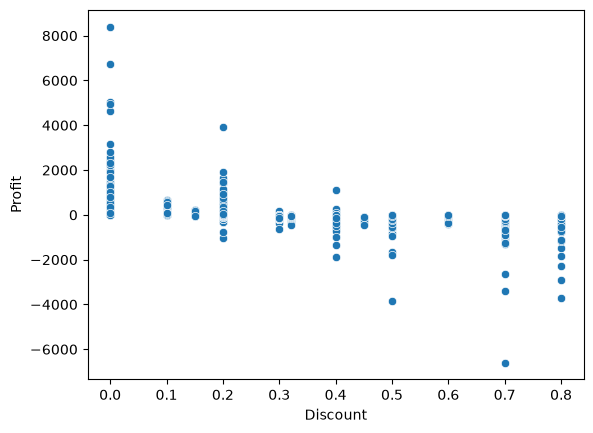

In [6]:
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit'
)

In [7]:
df.loc[
    df['Profit'].abs().nlargest(20).index,
    ['Order ID', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
]
# high negative profit is associated with high negative discount
# its normal in buisness
# so its not serious outlier so we can keep that

,Order ID,Product Name,Sales,Quantity,Discount,Profit
6826,CA-2016-118689,Canon imageCLASS 2200 Advanced Copier,17499.950,5,0.0,8399.9760
8153,CA-2017-140151,Canon imageCLASS 2200 Advanced Copier,13999.960,4,0.0,6719.9808
7772,CA-2016-108196,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
4190,CA-2017-166709,Canon imageCLASS 2200 Advanced Copier,10499.970,3,0.0,5039.9856
9039,CA-2016-117121,GBC Ibimaster 500 Manual ProClick Binding System,9892.740,13,0.0,4946.3700
4098,CA-2014-116904,Ibico EPK-21 Electric Binding System,9449.950,5,0.0,4630.4755
2623,CA-2017-127180,Canon imageCLASS 2200 Advanced Copier,11199.968,4,0.2,3919.9888
683,US-2017-168116,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,CA-2014-169019,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,CA-2017-134845,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800


# Feature Engineering

In [8]:
df['year'] = df['Order Date'].dt.year

df['month'] = df['Order Date'].dt.month

df['quarter'] = df['Order Date'].dt.quarter

df['day_of_week'] = df['Order Date'].dt.day_name()

df['sales_per_quantity'] = df['Sales'] / df['Quantity']

df['profit_margin'] = df['Profit'] / df['Sales']

df['shipping_days'] = (
    df['Ship Date'] - df['Order Date']
).dt.days

# Sales Analysis

In [9]:
print(df.groupby('Category')['Sales'].sum())
print(df['Sales'].sum())

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64
2297200.8603


In [10]:
print(df.groupby('Category')['Profit'].sum())
print(df['Profit'].sum())

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64
286397.0217


In [11]:
print(df.groupby('Category')['Quantity'].sum())
print(df['Quantity'].sum())

Category
Furniture           8028
Office Supplies    22906
Technology          6939
Name: Quantity, dtype: int64
37873


In [12]:
print(df.groupby('year')['Sales'].sum())

year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64


In [13]:
print(df.groupby('month')['Sales'].sum())

month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


In [14]:
print(df.groupby('Sub-Category')['Sales'].sum())
print(df['Sales'].sum())

Sub-Category
Accessories    167380.3180
Appliances     107532.1610
Art             27118.7920
Binders        203412.7330
Bookcases      114879.9963
Chairs         328449.1030
Copiers        149528.0300
Envelopes       16476.4020
Fasteners        3024.2800
Furnishings     91705.1640
Labels          12486.3120
Machines       189238.6310
Paper           78479.2060
Phones         330007.0540
Storage        223843.6080
Supplies        46673.5380
Tables         206965.5320
Name: Sales, dtype: float64
2297200.8603


In [15]:
print(df.groupby('Sub-Category')['Profit'].sum())
print(df['Profit'].sum())

Sub-Category
Accessories    41936.6357
Appliances     18138.0054
Art             6527.7870
Binders        30221.7633
Bookcases      -3472.5560
Chairs         26590.1663
Copiers        55617.8249
Envelopes       6964.1767
Fasteners        949.5182
Furnishings    13059.1436
Labels          5546.2540
Machines        3384.7569
Paper          34053.5693
Phones         44515.7306
Storage        21278.8264
Supplies       -1189.0995
Tables        -17725.4811
Name: Profit, dtype: float64
286397.0217


In [16]:
print(df.groupby('Order ID')['Sales'].sum().mean())

458.61466566180883


In [17]:
print(
    df.groupby(['year','Order ID'])['Sales']
    .sum()
    .groupby('year')
    .mean()
)

year
2014    499.739420
2015    453.306849
2016    463.274219
2017    434.626707
Name: Sales, dtype: float64


# Profitability Analysis

In [18]:
print(df.groupby('Category')['Profit'].sum().nlargest(5))

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


In [19]:
print(df.groupby('Sub-Category')['Profit'].sum().nlargest(20))

Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357
Paper          34053.5693
Binders        30221.7633
Chairs         26590.1663
Storage        21278.8264
Appliances     18138.0054
Furnishings    13059.1436
Envelopes       6964.1767
Art             6527.7870
Labels          5546.2540
Machines        3384.7569
Fasteners        949.5182
Supplies       -1189.0995
Bookcases      -3472.5560
Tables        -17725.4811
Name: Profit, dtype: float64


In [20]:
print(df.groupby('Sub-Category')['Sales'].mean().nlargest(20))

Sub-Category
Copiers        2198.941618
Machines       1645.553313
Tables          648.794771
Chairs          532.332420
Bookcases       503.859633
Phones          371.211534
Storage         264.590553
Supplies        245.650200
Appliances      230.755710
Accessories     215.974604
Binders         133.560560
Furnishings      95.825668
Envelopes        64.867724
Paper            57.284092
Labels           34.303055
Art              34.068834
Fasteners        13.936774
Name: Sales, dtype: float64


In [21]:
print(df.groupby(['Sub-Category'])['Sales'].sum().nlargest(20))

Sub-Category
Phones         330007.0540
Chairs         328449.1030
Storage        223843.6080
Tables         206965.5320
Binders        203412.7330
Machines       189238.6310
Accessories    167380.3180
Copiers        149528.0300
Bookcases      114879.9963
Appliances     107532.1610
Furnishings     91705.1640
Paper           78479.2060
Supplies        46673.5380
Art             27118.7920
Envelopes       16476.4020
Labels          12486.3120
Fasteners        3024.2800
Name: Sales, dtype: float64


In [22]:
df[
    (df['Sales'] >= df['Sales'].quantile(0.75)) &
    (df['Profit'] < 0)
][['Product Name', 'Sales', 'Profit', 'Discount']]

,Product Name,Sales,Profit,Discount
3,Bretford CR4500 Series Slim Rectangular Table,957.5775,-383.0310,0.45
27,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,-1665.0522,0.50
38,"Atlantic Metals Mobile 3-Shelf Bookcases, Cust...",532.3992,-46.9764,0.32
39,"Global Fabric Manager's Chair, Dark Gray",212.0580,-15.1470,0.30
66,"Global Value Mid-Back Manager's Chair, Gray",213.1150,-15.2225,0.30
...,...,...,...,...
9899,Chromcraft Bull-Nose Wood Oval Conference Tabl...,330.5880,-143.2548,0.40
9912,"Global Leather & Oak Executive Chair, Burgundy",362.1360,-54.3204,0.20
9919,Novimex Swivel Fabric Task Chair,528.4300,-143.4310,0.30
9931,O'Sullivan Living Dimensions 3-Shelf Bookcases,683.3320,-40.1960,0.15


In [23]:
df_LowPro_HiSal = (
    df.groupby('Product Name',as_index = False)
    .agg(
        sales = ('Sales','sum'),
        profit = ('Profit','sum')
    )
)

df_LowPro_HiSal[
    (df_LowPro_HiSal['sales'] >= df_LowPro_HiSal['sales'].quantile(0.75)) &
    (df_LowPro_HiSal['profit'] < 0)
].sort_values('sales',ascending = False)

,Product Name,sales,profit
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480,-1811.0784
683,GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662
813,High Speed Automatic Electric Letter Opener,17030.312,-262.0048
985,Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730
1043,Martin Yale Chadless Opener Electric Letter Op...,16656.200,-1299.1836
...,...,...,...
828,"Hon 30"" x 60"" Table with Locking Drawer",1296.028,-177.3512
1552,Tennsco Industrial Shelving,1281.442,-108.5802
386,Bush Somerset Collection Bookcase,1263.957,-56.3214
420,Case Logic 2.4GHz Wireless Keyboard,1229.754,-11.9976


In [24]:
product_profit = df.groupby('Product Name')['Profit'].sum()
print(product_profit[product_profit < 0])
print()
print(product_profit[product_profit < 0].nunique())

Product Name
3.6 Cubic Foot Counter Height Office Refrigerator                 -872.0752
36X48 HARDFLOOR CHAIRMAT                                           -40.4914
3D Systems Cube Printer, 2nd Generation, White                    -467.9964
3M Replacement Filter for Office Air Cleaner for 20' x 33' Room    -20.4768
ARKON Windshield Dashboard Air Vent Car Mount Holder               -15.5940
                                                                     ...   
XtraLife ClearVue Slant-D Ring Binders by Cardinal                 -13.3280
Zebra GK420t Direct Thermal/Thermal Transfer Printer              -938.2800
i.Sound Portable Power - 8000 mAh                                  -58.8189
iOttie HLCRIO102 Car Mount                                         -11.9940
iOttie XL Car Mount                                                -50.3748
Name: Profit, Length: 301, dtype: float64

301


print(df.groupby('Discount')['Profit'].sum())

In [25]:
print(df.groupby('Discount')['Sales'].sum())

Discount
0.00    1.087908e+06
0.10    5.436935e+04
0.15    2.755852e+04
0.20    7.645944e+05
0.30    1.032267e+05
0.32    1.449346e+04
0.40    1.164178e+05
0.45    5.484974e+03
0.50    5.891854e+04
0.60    6.644700e+03
0.70    4.062028e+04
0.80    1.696376e+04
Name: Sales, dtype: float64


# Customer Analysis 

In [26]:
print(df.groupby('Customer ID')['Sales'].sum().nlargest(10))

Customer ID
SM-20320    25043.050
TC-20980    19052.218
RB-19360    15117.339
TA-21385    14595.620
AB-10105    14473.571
KL-16645    14175.229
SC-20095    14142.334
HL-15040    12873.298
SE-20110    12209.438
CC-12370    12129.072
Name: Sales, dtype: float64


In [27]:
print(df.groupby('Customer ID')['Profit'].sum().nlargest(10))

Customer ID
TC-20980    8981.3239
RB-19360    6976.0959
SC-20095    5757.4119
HL-15040    5622.4292
AB-10105    5444.8055
TA-21385    4703.7883
CM-12385    3899.8904
KD-16495    3038.6254
AR-10540    2884.6208
DR-12940    2869.0760
Name: Profit, dtype: float64


In [28]:
print(df.groupby('Customer ID')['Order ID'].count().nlargest(10))

Customer ID
WB-21850    37
JL-15835    34
MA-17560    34
PP-18955    34
CK-12205    32
EH-13765    32
JD-15895    32
SV-20365    32
AP-10915    31
EP-13915    31
Name: Order ID, dtype: int64


In [29]:
# Average customer Spending
print(df.groupby('Customer ID')['Sales'].sum().mean())

2896.848499747793


In [30]:
print(df.groupby('Segment')['Customer ID'].nunique().nlargest(10))

Segment
Consumer       409
Corporate      236
Home Office    148
Name: Customer ID, dtype: int64


In [31]:
print('Sales by Segment')
print(df.groupby('Segment')['Sales'].sum())
print()
print('Profit by Segment')
print(df.groupby('Segment')['Profit'].sum())

Sales by Segment
Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64

Profit by Segment
Segment
Consumer       134119.2092
Corporate       91979.1340
Home Office     60298.6785
Name: Profit, dtype: float64


# Geographic Analysis

In [32]:
print(df.groupby('Region')['Sales'].sum().nlargest(5))

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [33]:
print(df.groupby('Region')['Profit'].sum().nlargest(5))

Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


In [34]:
filt = (df.groupby('State')['Profit'].sum())
print(filt[filt<0])

State
Arizona           -3427.9246
Colorado          -6527.8579
Florida           -3399.3017
Illinois         -12607.8870
North Carolina    -7490.9122
Ohio             -16971.3766
Oregon            -1190.4705
Pennsylvania     -15559.9603
Tennessee         -5341.6936
Texas            -25729.3563
Name: Profit, dtype: float64


In [35]:
# Sales concentration by region
print((df.groupby('Region')['Sales'].sum()/df['Sales'].sum() * 100).nlargest(5))

Region
West       31.580078
East       29.548188
Central    21.819594
South      17.052140
Name: Sales, dtype: float64


# Time Series Analysis

In [36]:
(df.groupby('year')[['Sales','Profit']].sum())

,Sales,Profit
year,,
2014,484247.4981,49543.9741
2015,470532.5090,61618.6037
2016,609205.5980,81795.1743
2017,733215.2552,93439.2696


In [37]:
(df.groupby('month')[['Sales','Profit']].sum()).sort_values(by = 'Profit',ascending = False)

,Sales,Profit
month,,
12,325293.5035,43369.1919
9,307649.9457,36857.4753
11,352461.0710,35468.4265
10,200322.9847,31784.0413
3,205005.4888,28594.6872
5,155028.8117,22411.3078
8,159044.0630,21776.9384
6,152718.6793,21285.7954
7,147238.0970,13832.6648


In [38]:
(df.groupby('quarter')[['Sales','Profit']].sum())

,Sales,Profit
quarter,,
1,359681.5758,48023.7440
2,445509.6196,55284.5395
3,613932.1057,72467.0785
4,878077.5592,110621.6597


In [39]:
((df.groupby('month')['Profit'].sum() / df.groupby('month')['Sales'].sum()).nlargest(12))
# according to profit/sales --> best or wost by profitability
# feb month is best
# april month is worst

month
2     0.172291
10    0.158664
5     0.144562
3     0.139483
6     0.139379
8     0.136924
12    0.133323
9     0.119803
11    0.100631
1     0.096228
7     0.093948
4     0.084112
dtype: float64

In [40]:
df.groupby('month')['Profit'].sum().idxmax()

np.int32(12)

In [41]:
# yearly growth
yearly_sales = df.groupby('year')['Sales'].sum()
yoy_growth_S = yearly_sales.pct_change() * 100
print(yoy_growth_S)

yearly_profit = df.groupby('year')['Profit'].sum()
yoy_growth_P = yearly_profit.pct_change() * 100
print(yoy_growth_P)

year
2014          NaN
2015    -2.832227
2016    29.471521
2017    20.355962
Name: Sales, dtype: float64
year
2014          NaN
2015    24.371540
2016    32.744284
2017    14.235675
Name: Profit, dtype: float64


In [42]:
yoy = pd.DataFrame({
    'Sales YoY %': yoy_growth_S ,
    'Profit YoY %': yoy_growth_P 
})

yoy

,Sales YoY %,Profit YoY %
year,,
2014,NaN,NaN
2015,-2.832227,24.371540
2016,29.471521,32.744284
2017,20.355962,14.235675


# Visualization

Text(0.5, 1.0, 'Monthly Sales')

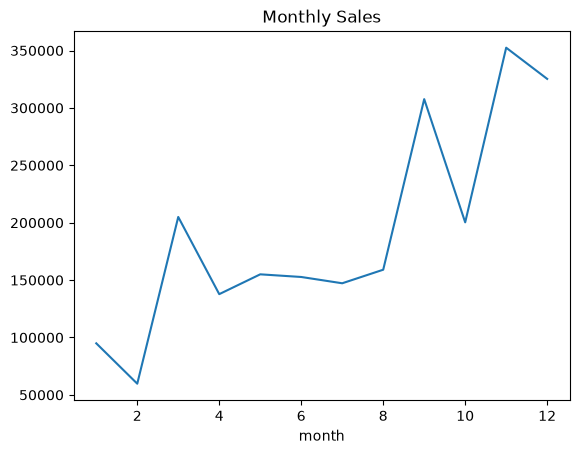

In [43]:
monthly_sales = df.groupby('month')['Sales'].sum()

sns.lineplot(
    x=monthly_sales.index,
    y=monthly_sales.values
)
plt.title('Monthly Sales')

Text(0.5, 1.0, 'Monthly Profit')

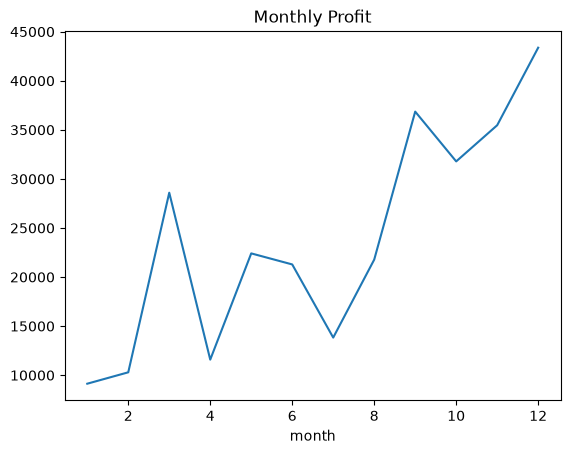

In [44]:
monthly_profit = df.groupby('month')['Profit'].sum()

sns.lineplot(
    x=monthly_profit.index,
    y=monthly_profit.values
)
plt.title('Monthly Profit')

Text(0.5, 1.0, 'Sales by Category')

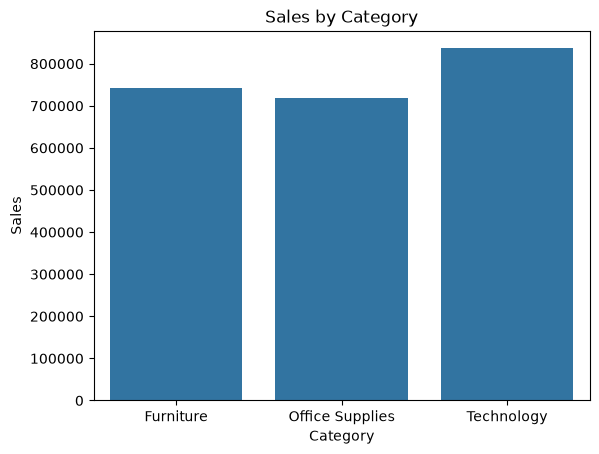

In [45]:
sns.barplot(
    data = df,
    x = 'Category',
    y = 'Sales',
    estimator = 'sum',
    errorbar = None
)
plt.title('Sales by Category')

Text(0.5, 1.0, 'Profit by Category')

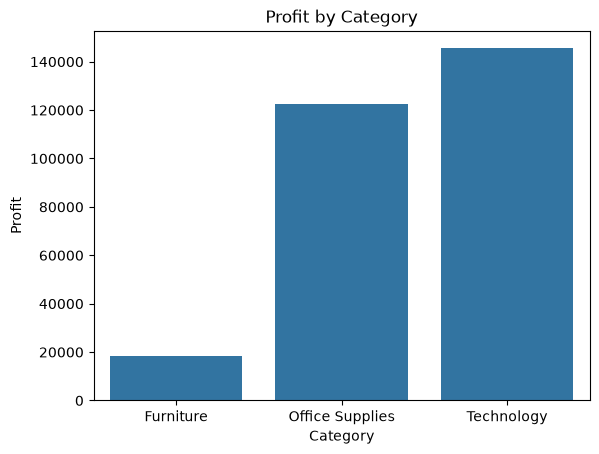

In [46]:
sns.barplot(
    data = df,
    x = 'Category',
    y = 'Profit',
    estimator = 'sum',
    errorbar = None
)
plt.title('Profit by Category')

Text(0.5, 1.0, 'Sales by Region')

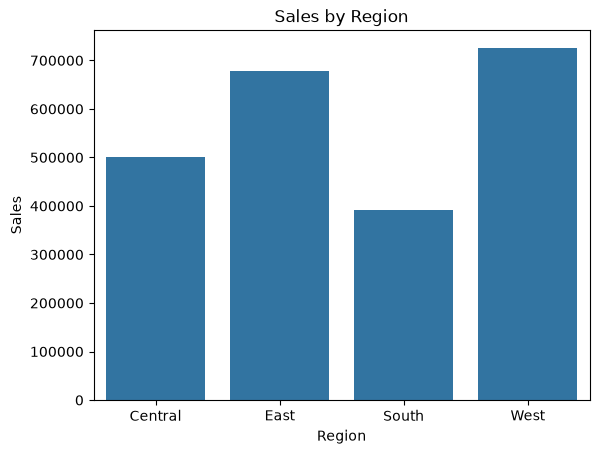

In [47]:
sns.barplot(
    data = df,
    x = 'Region',
    y = 'Sales',
    estimator = 'sum',
    errorbar = None,
)

plt.title('Sales by Region')

Text(0.5, 1.0, 'Profit by Each Region and Category')

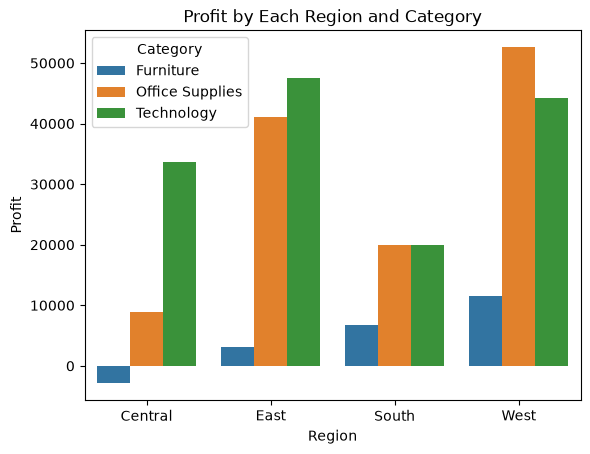

In [48]:
sns.barplot(
    data = df,
    x = 'Region',
    y = 'Profit',
    estimator = 'sum',
    errorbar = None,
    hue = 'Category'
)
plt.title('Profit by Each Region and Category')

Text(0.5, 1.0, 'Sales Distribution')

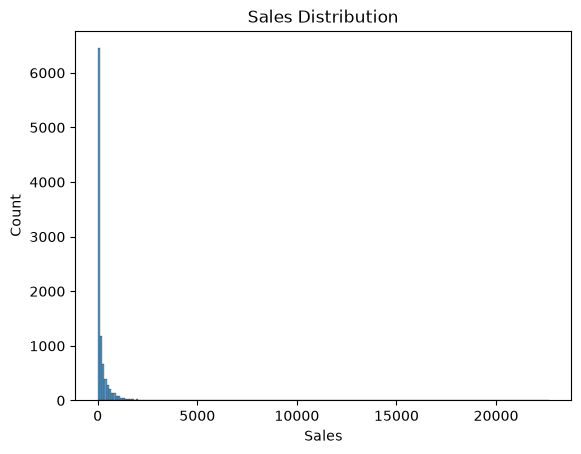

In [49]:
sns.histplot(
    data = df,
    x = 'Sales'
)
plt.title('Sales Distribution')

Text(0.5, 1.0, 'Sales Log Distribution')

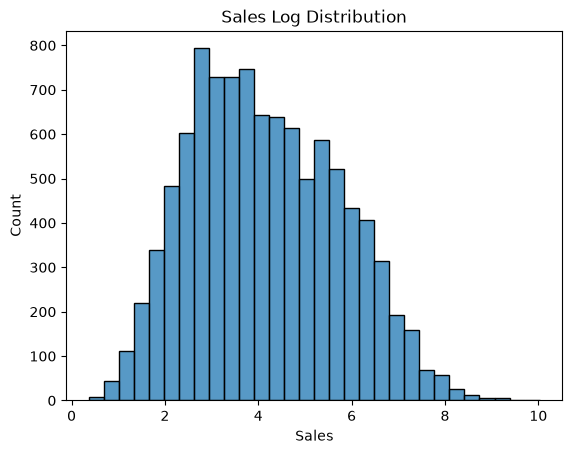

In [50]:
sns.histplot(x=np.log1p(df['Sales']), bins=30)
plt.title('Sales Log Distribution')

Text(0.5, 1.0, 'Sales BoxCox Distribution')

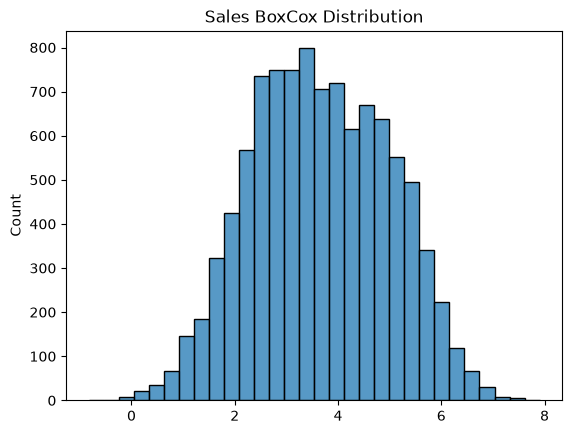

In [51]:
from scipy.stats import boxcox
sns.histplot(x=boxcox(df['Sales'])[0], bins=30)
plt.title('Sales BoxCox Distribution')

np.float64(7.561431562468341)

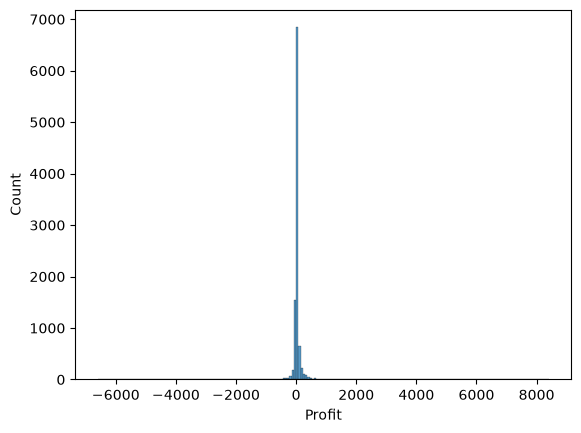

In [52]:
sns.histplot(
    data = df,
    x = 'Profit'
)

df['Profit'].skew()

In [53]:
from sklearn.preprocessing import PowerTransformer
from scipy.stats import skew

# Apply Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson')
profit_transformed = pt.fit_transform(df[['Profit']])

# Check skewness
print("Original skewness:", df['Profit'].skew())
print("Transformed skewness:", skew(profit_transformed.ravel(), bias=False))


Original skewness: 7.561431562468341
Transformed skewness: 3.728368377147876


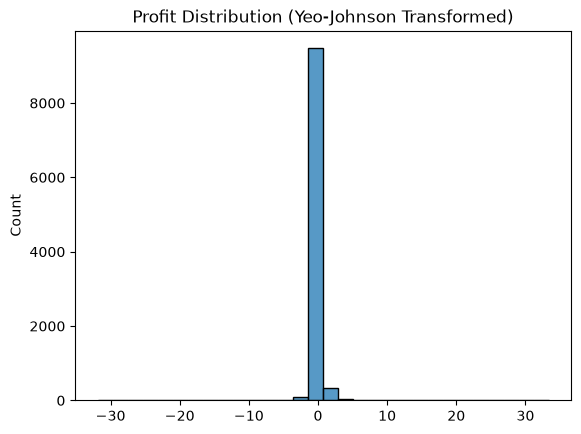

In [54]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')
profit_transformed = pt.fit_transform(df[['Profit']])

sns.histplot(x=profit_transformed.ravel(), bins=30)
plt.title("Profit Distribution (Yeo-Johnson Transformed)")
plt.show()

Text(0.5, 1.0, 'Discount vs Profit')

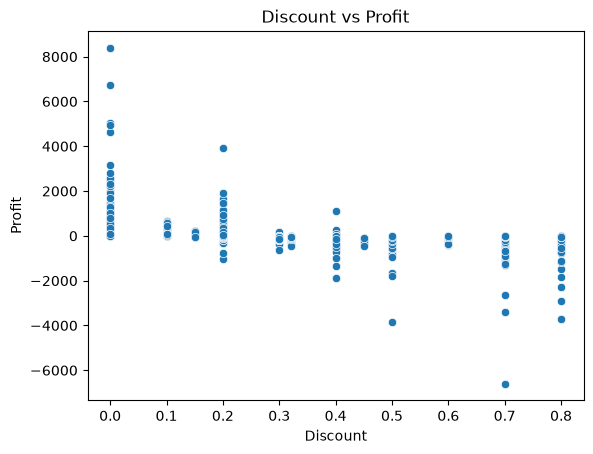

In [55]:
sns.scatterplot(
    data = df,
    x = 'Discount',
    y = 'Profit'
)
plt.title('Discount vs Profit')

Text(0.5, 1.0, 'Sales vs Profit')

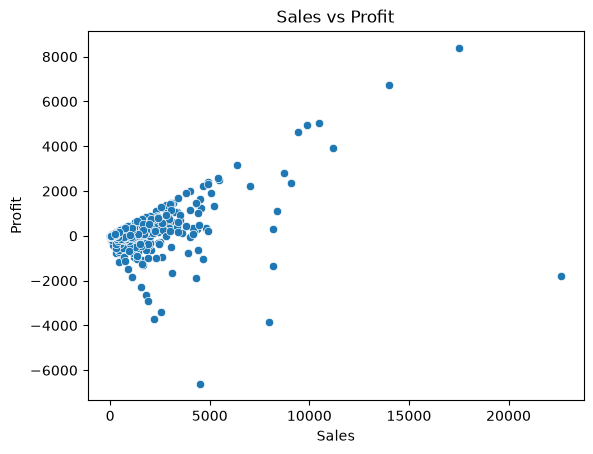

In [56]:
sns.scatterplot(
    data = df,
    x = 'Sales',
    y = 'Profit'
)
plt.title("Sales vs Profit")

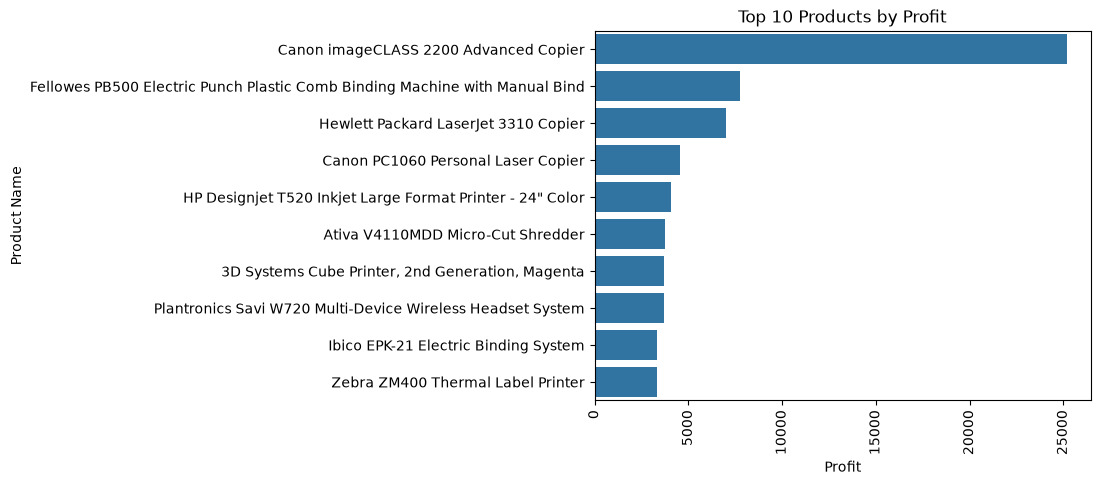

In [57]:
top_10_products = df.groupby('Product Name')['Profit'].sum().nlargest(10).reset_index()

sns.barplot(
    data = top_10_products,
    y = 'Product Name',
    x = 'Profit'
)
plt.xticks(rotation=90)
plt.title("Top 10 Products by Profit")
plt.show()

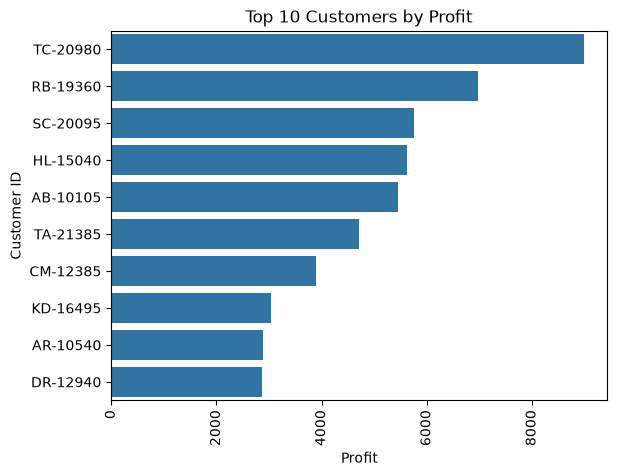

In [58]:
top_10_Customers = df.groupby('Customer ID')['Profit'].sum().nlargest(10).reset_index()

sns.barplot(
    data = top_10_Customers,
    y = 'Customer ID',
    x = 'Profit'
)
plt.xticks(rotation=90)
plt.title("Top 10 Customers by Profit")
plt.show()

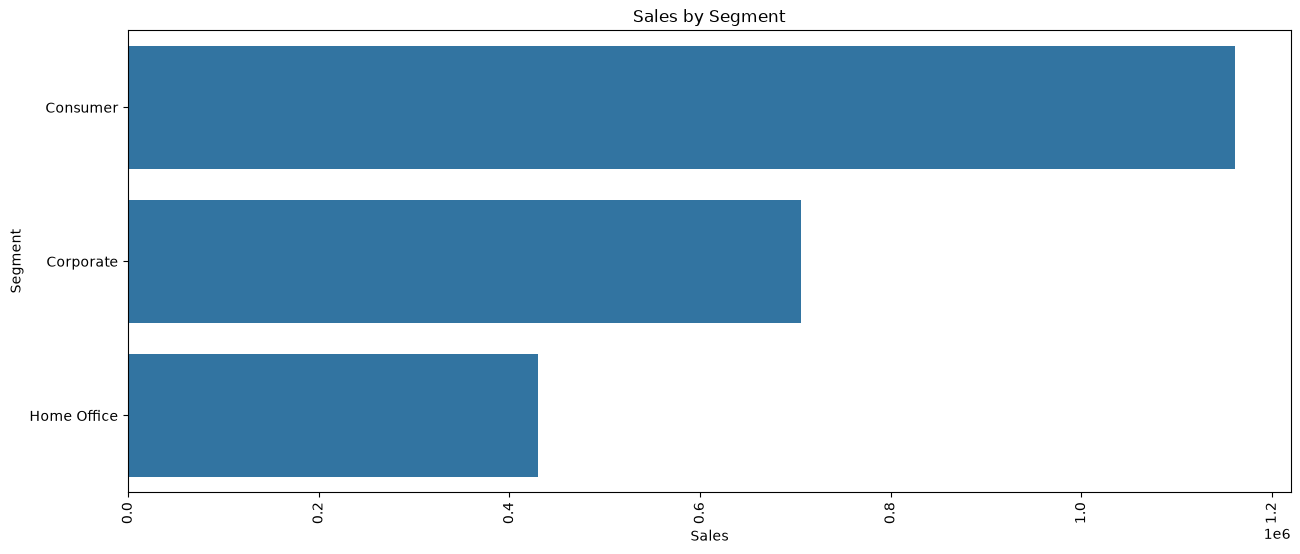

In [59]:
sales_by_segment = df.groupby('Segment')['Sales'].sum().reset_index()
plt.figure(figsize =(15,6))
sns.barplot(
    data = sales_by_segment,
    y = 'Segment',
    x = 'Sales'
)
plt.xticks(rotation=90)
plt.title("Sales by Segment")
plt.show()

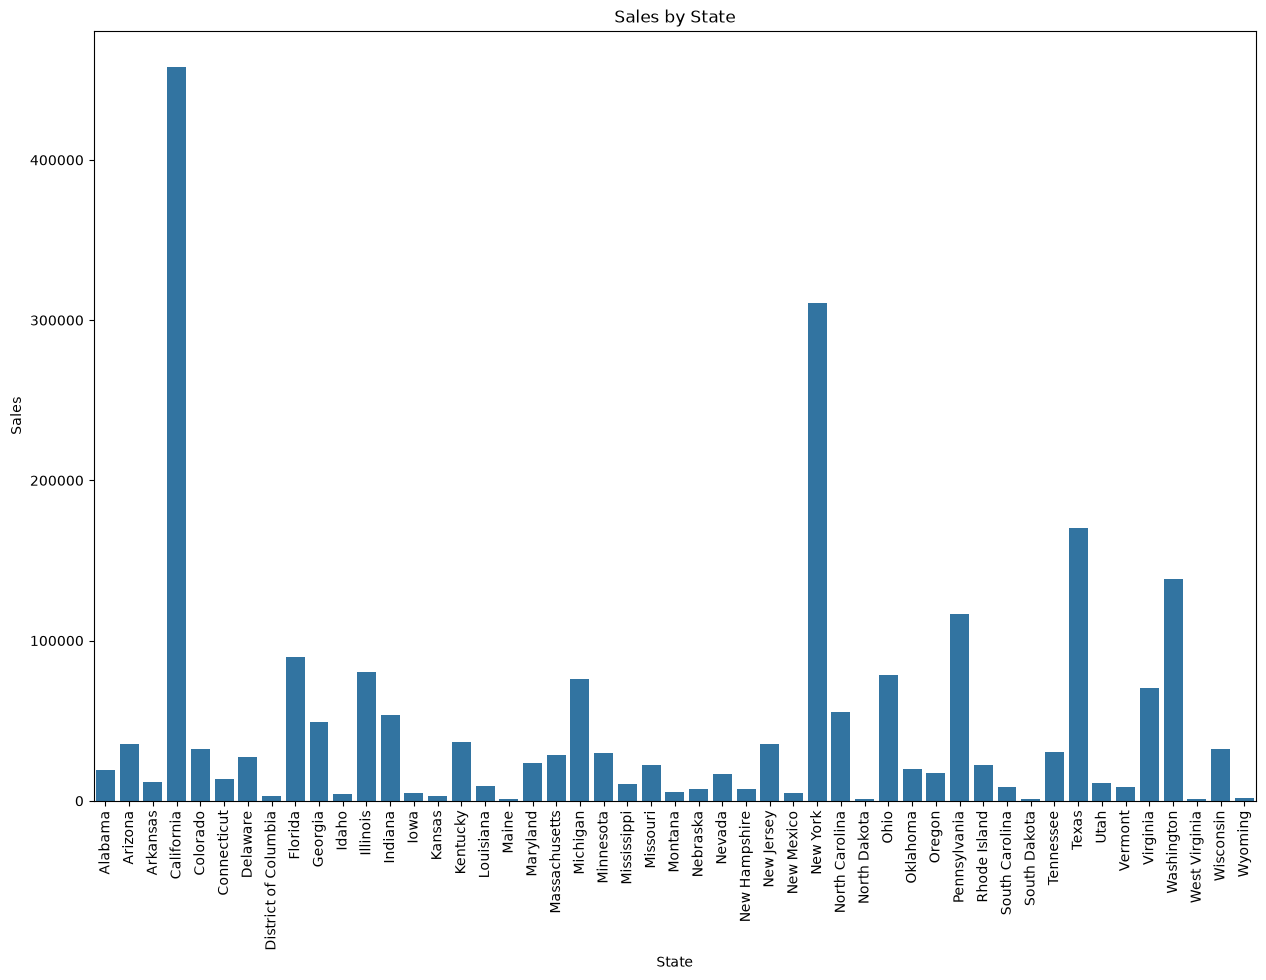

In [60]:
sales_by_state = df.groupby('State')['Sales'].sum().reset_index()
plt.figure(figsize = (15,10))
sns.barplot(
    data = sales_by_state,
    x = 'State',
    y = 'Sales'
)
plt.xticks(rotation=90)
plt.title("Sales by State")
plt.show()


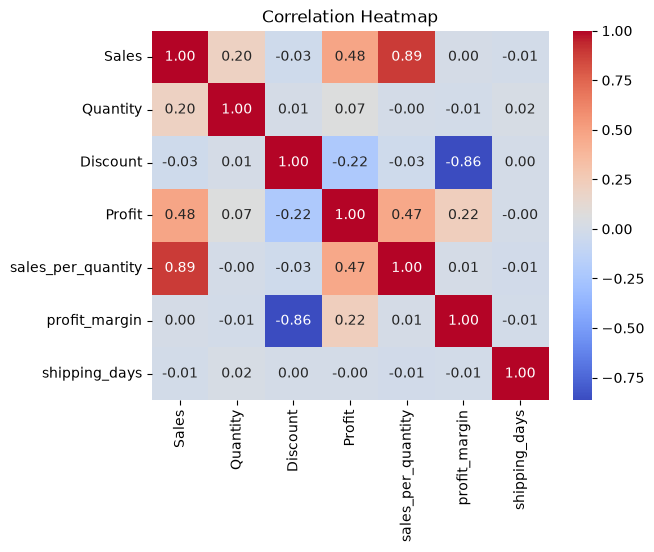

In [61]:
corr_cols = [
    'Sales',
    'Quantity',
    'Discount',
    'Profit',
    'sales_per_quantity',
    'profit_margin',
    'shipping_days'
]

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

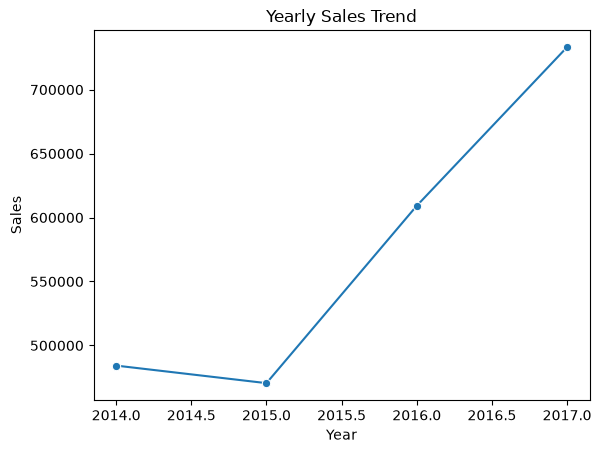

In [62]:
yearly_sales = df.groupby('year')['Sales'].sum()

sns.lineplot(
    x=yearly_sales.index,
    y=yearly_sales.values,
    marker='o'
)

plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

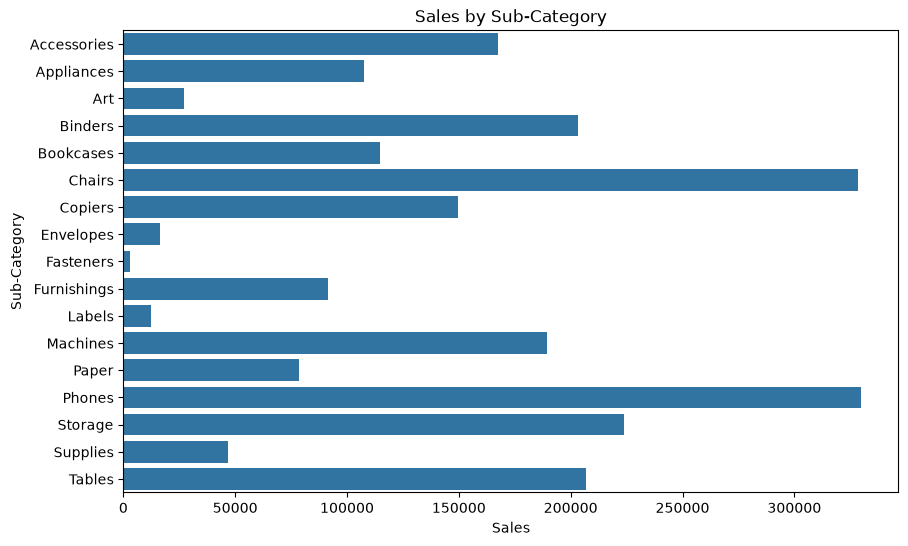

In [63]:
subcategory_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=subcategory_sales.values,
    y=subcategory_sales.index
)

plt.title('Sales by Sub-Category')
plt.xlabel('Sales')
plt.ylabel('Sub-Category')
plt.show()

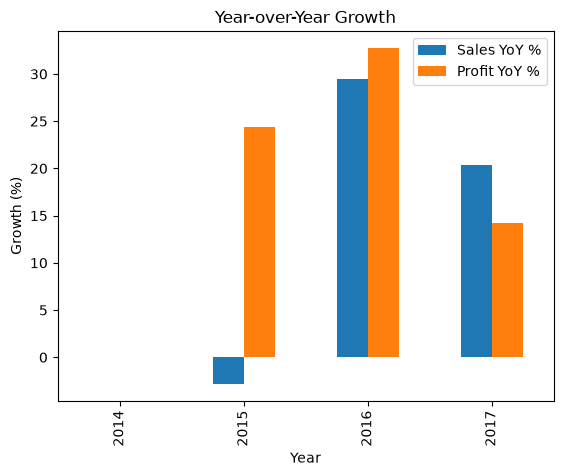

In [64]:
yoy.plot(kind='bar')

plt.title('Year-over-Year Growth')
plt.ylabel('Growth (%)')
plt.xlabel('Year')
plt.show()

#  Business Insights — Sales Analysis

##  Overall Performance

- **Total Sales: 2.297M**
- **Total Profit: 286.4K**
- **Total Quantity Sold: 37,873**
- **Average Order Value: 458.61**
- **Average Customer Spending: 2,896.85**
- **Overall Profit Margin: 12.5%**

---

##  Category Insights

- **Technology has the highest sales and highest profit** among all categories.
- **Furniture generates high sales but comparatively low profit.**
- Furniture generates approximately **742K in sales but only 18.45K in profit**, indicating weak profitability.
- Office Supplies generates **122.5K profit** despite having lower sales than Technology.
- **Furniture is the main category requiring profitability improvement.**

---

##  Sub-Category Insights

- **Copiers generate the highest profit** among all sub-categories at approximately **55.6K**.
- **Phones and Accessories** are also among the most profitable sub-categories.
- **Tables are the biggest loss-making sub-category**, with approximately **17.7K loss**.
- Bookcases and Supplies also generate **negative profit**.
- **High sales do not necessarily mean high profitability**, as demonstrated by the Tables sub-category.

---

##  High-Sales Low-Profit Products

- **301 products have negative overall profit.**
- Several products generate significant sales while still producing losses.
- **High-sales loss-making products should be investigated first** because they have a large impact on overall profitability.
- The analysis identified products with **high sales but negative profit**, indicating potential issues with pricing, discounts, or costs.
- These products should be reviewed individually before increasing their sales further.

---

##  Discount Insights

- **Higher discounts can significantly reduce profitability.**
- Loss-making products should be investigated for **excessive discounting**.
- A product can generate high sales while still producing a loss when discounts are too aggressive.
- **Discount strategies should consider profit margin, not sales alone.**

---

##  Customer Insights

- **Consumer is the largest customer segment**, with 409 unique customers.
- Corporate has **236 unique customers**.
- Home Office has **148 unique customers**.
- **Consumer generates the highest sales and highest profit** among the three segments.
- The customer with the highest sales is not necessarily the customer with the highest profit.
- **Customer profitability should be considered along with customer spending.**

---

##  Geographic Insights

- **West is the strongest region in both sales and profit.**
- East is the second-highest region in both sales and profit.
- Central generates higher sales than South but lower profit.
- South generates lower sales than Central but higher profit.
- **Several states generate negative profit and require further investigation.**
- Geographic performance shows that **sales volume alone does not determine profitability.**

---

##  Yearly Performance

- Sales decreased by approximately **2.83% in 2015**.
- Despite the sales decline, **profit increased by approximately 24.37% in 2015**.
- Sales increased by approximately **29.47% in 2016**.
- Profit increased by approximately **32.74% in 2016**.
- Sales increased by approximately **20.36% in 2017**.
- Profit increased by approximately **14.24% in 2017**.
- **Overall business performance improved significantly after 2015.**
- 2016 recorded the **strongest profit growth** among the observed years.

---

##  Monthly Performance

- **December has the highest total monthly profit** at approximately 43.4K.
- **February has the highest profit margin** at approximately 17.23%.
- **April has the lowest profit margin** at approximately 8.41%.
- The month with the highest total profit is not necessarily the month with the highest profit margin.
- **Monthly profitability varies significantly throughout the year.**

---

##  Key Business Findings

- **Technology is the strongest overall category** in terms of both sales and profit.
- **Furniture is the major profitability concern** because of its high sales but relatively low profit.
- **Tables are the biggest loss-making sub-category.**
- **301 products generate negative overall profit**, requiring further product-level investigation.
- **Discounting is an important factor to investigate in loss-making products.**
- **West is the strongest-performing region** in both sales and profit.
- **Consumer is the largest and most profitable customer segment.**
- **Profit grew faster than sales in 2015 and 2016**, indicating improved profitability during those years.
- **February has the best profit margin, while April has the weakest.**

---

##  Business Recommendations

- **Investigate Furniture and Tables** to identify pricing, discount, or cost-related problems.
- **Review high-sales but loss-making products** before attempting to increase their sales.
- Reduce excessive discounts on products with poor or negative profit margins.
- Focus marketing efforts on **high-profit sub-categories such as Copiers, Phones, and Accessories**.
- Investigate states with persistent negative profit.
- Use **profitability together with sales** when identifying valuable customers and products.
- Analyze monthly patterns to better plan promotions and inventory.
- Maintain strong performance in the **West region** while investigating weaker regions and states.
- **Prioritize profit growth rather than sales growth alone.**

---

##  Final Business Conclusion

> **The business generates strong overall sales and positive profitability, but sales volume does not always translate into profit. Technology, Copiers, Phones, and the West region are major strengths, while Furniture, Tables, and several high-sales loss-making products require attention. Discount optimization, product-level profitability analysis, and regional improvement can help increase overall business profitability.**